# 1 · Data pipeline — CHIRPS → Kerala LR/HR pairs

Turns 30 years of raw global CHIRPS files into the paired low-res / high-res
arrays the model trains on.

| Step | Input | Output | Runtime |
|---|---|---|---|
| 1 · Combine + clip | `Downscaling/chirps/` (30 files, ~33 GB) | `chirps_1996_2025_clipped.nc` | slow — tens of minutes |
| 2 · Build pairs | the clipped file | `paired_data.npz` | ~1 min |

**Step 1 is already done.** Its output is on disk, so `RUN_CLIP` below defaults to
`False`. Set it to `True` only if you need to rebuild from the raw archive.

The low-res field is derived *from* the high-res field by 5×5 block-averaging, so
the training pairs are self-supervised — no second dataset, no cross-sensor bias.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401  (registers the .rio accessor)
import xarray as xr

CWD = Path.cwd()
PROJECT = CWD.parent if CWD.name == "notebooks" else CWD

DATA = PROJECT / "Downscaling"
RESULTS = PROJECT / "results"
FIGURES = PROJECT / "figures"

CHIRPS_RAW = DATA / "chirps"
CHIRPS_CLIPPED = DATA / "chirps_1996_2025_clipped.nc"
STATE_GEOJSON = DATA / "state.geojson"
PAIRED_DATA = DATA / "paired_data.npz"

for d in (RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

YEARS = range(1996, 2026)
FACTOR = 5

def rel(p):
    """Path relative to the project root — keeps machine paths out of committed output."""
    return p.relative_to(PROJECT)  # 0.25 / 0.05 = 5 exactly

print("project root:", PROJECT.name + "/")
print("clipped file exists:", CHIRPS_CLIPPED.exists())

project root: dushyant/
clipped file exists: True


## Step 1 — Combine and clip the raw CHIRPS archive

Opens each yearly global file lazily with dask, clips it to the Kerala boundary,
then concatenates along time. `all_touched=True` keeps any cell the boundary
passes through, which is why the result has a ragged coastal edge.

In [2]:
RUN_CLIP = False  # set True to rebuild chirps_1996_2025_clipped.nc from the raw archive

state = gpd.read_file(STATE_GEOJSON)
print(f"boundary: {state['ST_NM'].tolist()} | bounds={state.total_bounds}")


def clip_to_state(ds, x_dim, y_dim):
    ds = ds.rio.set_spatial_dims(x_dim=x_dim, y_dim=y_dim)
    ds = ds.rio.write_crs("EPSG:4326", inplace=True)
    return ds.rio.clip(state.geometry.values, state.crs, drop=True, all_touched=True)


def build_clipped():
    yearly = []
    for year in YEARS:
        path = CHIRPS_RAW / f"chirps-v2.0.{year}.days_p05.nc"
        if not path.exists():
            print(f"  missing: {path}")
            continue
        ds = xr.open_dataset(path, chunks={"time": 50, "latitude": 400, "longitude": 400})
        clipped = clip_to_state(ds, "longitude", "latitude").chunk({"time": 366})
        yearly.append(clipped)
        print(f"  {year}: clipped shape {dict(clipped.sizes)}")

    combined = xr.concat(yearly, dim="time", coords="minimal", compat="override").sortby("time")
    print(f"  combined shape: {dict(combined.sizes)}")
    encoding = {v: {"zlib": True, "complevel": 4} for v in combined.data_vars}
    combined.to_netcdf(CHIRPS_CLIPPED, encoding=encoding)
    print(f"  saved -> {rel(CHIRPS_CLIPPED)}")


if RUN_CLIP:
    build_clipped()
else:
    print("skipped (RUN_CLIP=False) — using the existing clipped file")

boundary: ['Kerala'] | bounds=[74.86303797  8.29135592 77.41268705 12.79508011]
skipped (RUN_CLIP=False) — using the existing clipped file


## Step 2 — Build the paired LR/HR arrays

`0.25 / 0.05 = 5` exactly, so the native 91×52 clipped grid is cropped to **90×50** —
the largest clean multiple of 5 in each dimension — and 5×5 tiles are averaged down
to an **18×10** low-res grid.

In [3]:
ds = xr.open_dataset(CHIRPS_CLIPPED)
n_lat, n_lon = ds.sizes["latitude"], ds.sizes["longitude"]
h_crop = (n_lat // FACTOR) * FACTOR   # 90
w_crop = (n_lon // FACTOR) * FACTOR   # 50
h_lr, w_lr = h_crop // FACTOR, w_crop // FACTOR

print(f"native {n_lat}x{n_lon} -> cropped {h_crop}x{w_crop} -> LR {h_lr}x{w_lr}")

ds = ds.isel(latitude=slice(0, h_crop), longitude=slice(0, w_crop))
lat_hr = ds["latitude"].values
lon_hr = ds["longitude"].values
dates = ds["time"].values

hr = ds["precip"].values.astype("float32")          # (N, 90, 50)
mask_hr = ~np.isnan(hr[0])
assert np.all((~np.isnan(hr)) == mask_hr[None]), "CHIRPS mask varies by day, unexpected"
hr_filled = np.where(mask_hr[None], np.nan_to_num(hr, nan=0.0), 0.0)

print(f"days: {hr.shape[0]}  |  {str(dates[0])[:10]} to {str(dates[-1])[:10]}")

native 91x52 -> cropped 90x50 -> LR 18x10


days: 10958  |  1996-01-01 to 2025-12-31


The block mean divides by the number of **valid** (in-mask) cells, not by 25.
That matters: only 33 of the 78 data-carrying LR blocks sit fully inside Kerala —
the other 45 straddle the coast or border, where the two definitions differ.
Anything that later pools the high-res field back down has to divide the same way.

In [4]:
n = hr.shape[0]
valid = mask_hr[None].repeat(n, axis=0).astype("float32")

hr_blocks = hr_filled.reshape(n, h_lr, FACTOR, w_lr, FACTOR)
valid_blocks = valid.reshape(n, h_lr, FACTOR, w_lr, FACTOR)

sums = hr_blocks.sum(axis=(2, 4))
counts = valid_blocks.sum(axis=(2, 4))
with np.errstate(invalid="ignore"):
    lr = np.where(counts > 0, sums / counts, np.nan).astype("float32")

mask_lr = counts[0] > 0
lat_lr = lat_hr.reshape(h_lr, FACTOR).mean(axis=1)
lon_lr = lon_hr.reshape(w_lr, FACTOR).mean(axis=1)

cells = counts[0]
full = int((cells == FACTOR ** 2).sum())
partial = int(((cells > 0) & (cells < FACTOR ** 2)).sum())

print(f"HR {hr.shape}  LR {lr.shape}")
print(f"HR mask cells: {mask_hr.sum()}/{mask_hr.size}   LR blocks with data: {mask_lr.sum()}/{mask_lr.size}")
print(f"  of those: {full} fully inside the mask, {partial} partial ({100*partial/mask_lr.sum():.0f}%)")
print(f"HR range [{np.nanmin(hr):.2f}, {np.nanmax(hr):.2f}] mm/day")
print(f"LR range [{np.nanmin(lr):.2f}, {np.nanmax(lr):.2f}] mm/day")

HR (10958, 90, 50)  LR (10958, 18, 10)
HR mask cells: 1443/4500   LR blocks with data: 78/180
  of those: 33 fully inside the mask, 45 partial (58%)
HR range [0.00, 578.37] mm/day
LR range [0.00, 505.99] mm/day


In [5]:
# zero-fill outside the mask for storage, consistent with the rest of the project
hr_out = np.where(mask_hr[None], hr_filled, 0.0).astype("float32")
lr_out = np.where(mask_lr[None], np.nan_to_num(lr, nan=0.0), 0.0).astype("float32")

np.savez_compressed(
    PAIRED_DATA,
    hr=hr_out, lr=lr_out, mask_hr=mask_hr, mask_lr=mask_lr,
    dates=dates, lat_hr=lat_hr, lon_hr=lon_hr, lat_lr=lat_lr, lon_lr=lon_lr,
)
print("saved ->", rel(PAIRED_DATA), f"({PAIRED_DATA.stat().st_size/1e6:.1f} MB)")

saved -> Downscaling/paired_data.npz (20.6 MB)


## Sanity check

The wettest day in the record, low-res beside high-res. The low-res panel should
look like a blocky version of the same storm — if the two disagree in position,
the crop or the block reshape is misaligned.

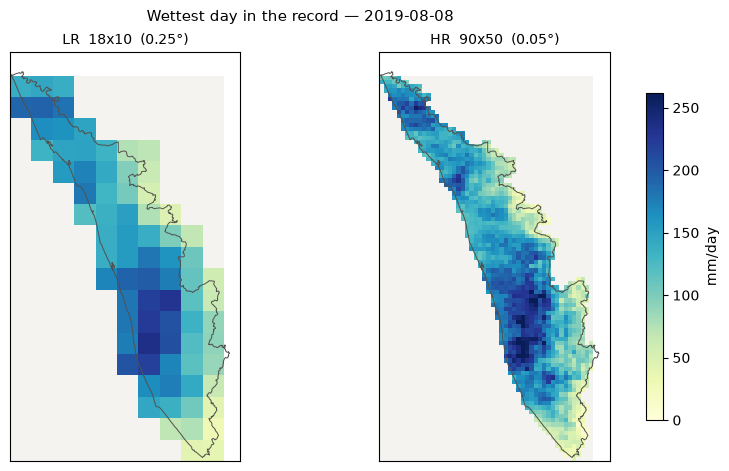

In [6]:
day = int(np.nanmean(np.where(mask_hr[None], hr, np.nan), axis=(1, 2)).argmax())
vmax = float(np.nanpercentile(hr[day][mask_hr], 99))

cmap = plt.get_cmap("YlGnBu").copy()
cmap.set_bad("#f4f3f0")

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.6), constrained_layout=True)
for ax, (title, field, la, lo) in zip(axes, [
        (f"LR  {h_lr}x{w_lr}  (0.25°)", np.where(mask_lr, lr[day], np.nan), lat_lr, lon_lr),
        (f"HR  {h_crop}x{w_crop}  (0.05°)", np.where(mask_hr, hr[day], np.nan), lat_hr, lon_hr)]):
    pcm = ax.pcolormesh(lo, la, field, cmap=cmap, vmin=0, vmax=vmax, shading="auto")
    state.boundary.plot(ax=ax, color="#52514e", linewidth=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(pcm, ax=axes, shrink=0.8, label="mm/day")
fig.suptitle(f"Wettest day in the record — {str(dates[day])[:10]}", fontsize=11)
plt.show()